# Retail Demand Forecasting — Walmart M5 Sales Pipeline

## Project Overview

This notebook implements an end-to-end retail demand forecasting pipeline
built on the M5 Forecasting (Walmart) dataset. It covers data ingestion,
memory-efficient feature engineering at scale, exploratory analysis of sales
and pricing patterns, model training and comparison, and a 28-day recursive
forecast that powers the companion Streamlit application.

## Design Principles

- **Scales independently of dataset size.** Product selection (`TOP_N`) and
  processing batch size (`CHUNK_SIZE`) are decoupled — peak memory usage is
  governed only by `CHUNK_SIZE`, so `TOP_N` can be raised from 15 to 1,500+
  without changing how the pipeline runs.
- **Category-balanced by design.** Products are selected proportionally
  across categories (`FOODS`, `HOUSEHOLD`, `HOBBIES`) rather than by raw
  sales volume alone, so the model trains on a representative product mix
  instead of being dominated by the largest category.
- **Memory-aware at every stage.** Numeric and categorical columns are
  downcast to the smallest safe dtype throughout, EDA statistics are
  accumulated incrementally rather than computed on a fully materialized
  table, and intermediate frames are released as soon as they're no longer
  needed.
- **Model choice is evidence-based.** XGBoost and LightGBM are trained and
  compared on identical features and metrics; an optional LSTM baseline is
  included for completeness, with a documented rationale for why gradient
  boosting is the stronger default for this dataset.

## Notebook Structure

1. Data loading & category-balanced product selection
2. Chunked feature engineering pipeline
3. Exploratory Data Analysis
4. Data cleaning & preprocessing (recap)
5. Time-series feature engineering (recap)
6. Chronological train/test split
7. Baseline model: XGBoost
8. Model comparison: LightGBM & optional deep learning baseline
9. Recursive 28-day forecasting & deployment artifacts
10. Deployment via Streamlit


In [1]:
# Data Analysis Libraries
import pandas as pd
import numpy as np
import gc
import warnings

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Modeling Libraries
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

pd.set_option('display.max_columns', None)
warnings.filterwarnings('ignore', category=FutureWarning)


In [2]:
def reduce_mem_usage(df, verbose=False):
    """Downcast numeric columns to the smallest dtype that fits, in place."""
    numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
    start_mem = df.memory_usage().sum() / 1024**2
    for col in df.columns:
        col_type = df[col].dtypes
        if col_type in numerics:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                else:
                    df[col] = df[col].astype(np.int64)
            else:
                if c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
    end_mem = df.memory_usage().sum() / 1024**2
    if verbose:
        print(f'Memory usage: {start_mem:.2f} MB -> {end_mem:.2f} MB '
              f'({100*(start_mem-end_mem)/start_mem:.1f}% reduction)')
    return df


def print_memory_usage(label=''):
    """Best-effort process RAM report. Falls back quietly if psutil isn't installed."""
    try:
        import psutil, os
        rss_mb = psutil.Process(os.getpid()).memory_info().rss / 1024**2
        print(f'[memory] {label}: {rss_mb:.1f} MB in use')
    except ImportError:
        pass


## Step 1 — Data Loading & Product Selection

`calendar.csv` and `sell_prices.csv` are loaded directly. `sales_train_validation.csv`
is loaded in its original *wide* format — one row per product-store
combination with one column per day — since reshaping it before selecting
products would force the full dataset into memory unnecessarily. Categorical
columns are cast to compact dtypes immediately, before any melting or
merging takes place.


In [3]:
# Getting the uploaded data from Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
DATA_DIR = '/content/drive/MyDrive/DEPI/DEPI_Grad_Project/data/'  # <-- change to your path, e.g. '/content/drive/MyDrive/DEPI/DEPI_Grad_Project/data/'

calendar = pd.read_csv(DATA_DIR + 'calendar.csv', parse_dates=['date'])
sell_prices = pd.read_csv(DATA_DIR + 'sell_prices.csv')

for c in ['weekday', 'event_name_1', 'event_type_1', 'event_name_2', 'event_type_2']:
    if c in calendar.columns:
        calendar[c] = calendar[c].astype('category')

id_dtypes = {'id': 'category', 'item_id': 'category', 'dept_id': 'category',
             'cat_id': 'category', 'store_id': 'category', 'state_id': 'category'}
sales_wide = pd.read_csv(DATA_DIR + 'sales_train_validation.csv', dtype=id_dtypes)

d_cols = [c for c in sales_wide.columns if c.startswith('d_')]
sales_wide[d_cols] = sales_wide[d_cols].astype('int16')

print('Raw wide shape:', sales_wide.shape)
print_memory_usage('after loading raw files')


Raw wide shape: (30490, 1919)
[memory] after loading raw files: 999.8 MB in use


### Product Selection: `TOP_N`, `CHUNK_SIZE`, and Category Balance

Two independent parameters control the scope and scale of this pipeline:

- **`TOP_N`** — the total number of distinct products included in training
  and forecasting.
- **`CHUNK_SIZE`** — the number of products processed together in a single
  batch.

**Category-balanced selection.** Ranking products purely by total units sold
would bias the selection toward whichever category has the most SKUs (in
this dataset, `FOODS`). To avoid under-representing `HOBBIES` and
`HOUSEHOLD`, `TOP_N` is allocated proportionally to each category's share of
unique items, and the top sellers are then drawn from *within* each
category. The breakdown of how many products came from each category is
printed below and visualized as a chart.

**Memory-independent scaling.** `TARGET_ITEMS` is split into batches of
`CHUNK_SIZE` products; each batch is melted, merged, cleaned, and
feature-engineered independently, and only the compact, feature-ready result
is retained. Peak memory therefore depends on `CHUNK_SIZE`, not on `TOP_N` —
`TOP_N` can be set to 15 or 1,500 without changing the notebook's memory
profile, only its runtime.

As a practical guideline on a free-tier Colab runtime (~12 GB RAM), keep
`CHUNK_SIZE` in the 150–250 range even when `TOP_N` exceeds 1,000.


In [5]:
# ============================================================
# Product universe: TOP_N controls how many distinct products the
# Streamlit app will ultimately serve. CHUNK_SIZE controls peak memory
# usage during processing and is chosen independently of TOP_N.
# ============================================================
TOP_N = 1000       # total distinct products to keep — raise freely
CHUNK_SIZE = 200    # products processed per batch — lower this if you hit memory limits

total_sales_rank = sales_wide[d_cols].sum(axis=1)  # transient, used only to rank

# --- Stratified (category-balanced) selection ---
# A flat "top N overall" ranking is dominated by the category with the most
# SKUs. Instead we allocate TOP_N across categories proportionally to each
# category's share of unique items, then take that category's best sellers.
item_rank_by_cat = (
    sales_wide.assign(_rank=total_sales_rank)
    .groupby(['cat_id', 'item_id'], observed=True)['_rank']
    .sum()
    .reset_index()
)

category_item_counts = item_rank_by_cat.groupby('cat_id', observed=True)['item_id'].nunique()
category_quota = (category_item_counts / category_item_counts.sum() * TOP_N).round().astype(int)

# Rounding can leave the total a few products short of / over TOP_N —
# adjust the largest category so the final count matches TOP_N exactly.
quota_gap = TOP_N - category_quota.sum()
category_quota.iloc[category_quota.values.argmax()] += quota_gap


In [6]:
TARGET_ITEMS = []
for cat_id, quota in category_quota.items():
    top_items_in_category = (
        item_rank_by_cat.loc[item_rank_by_cat['cat_id'] == cat_id]
        .nlargest(quota, '_rank')['item_id']
        .tolist()
    )
    TARGET_ITEMS.extend(top_items_in_category)

print(f'Selected {len(TARGET_ITEMS)} products across {len(category_quota)} categories:')
for cat_id, quota in category_quota.items():
    print(f'  - {cat_id:<10}: {quota:>4} products selected (of {category_item_counts[cat_id]} available)')

item_chunks = [TARGET_ITEMS[i:i + CHUNK_SIZE] for i in range(0, len(TARGET_ITEMS), CHUNK_SIZE)]
print(f'\nSplit into {len(item_chunks)} chunk(s) of up to {CHUNK_SIZE} products each.')


Selected 1000 products across 3 categories:
  - HOBBIES   :  185 products selected (of 565 available)
  - HOUSEHOLD :  343 products selected (of 1047 available)
  - FOODS     :  472 products selected (of 1437 available)

Split into 5 chunk(s) of up to 200 products each.


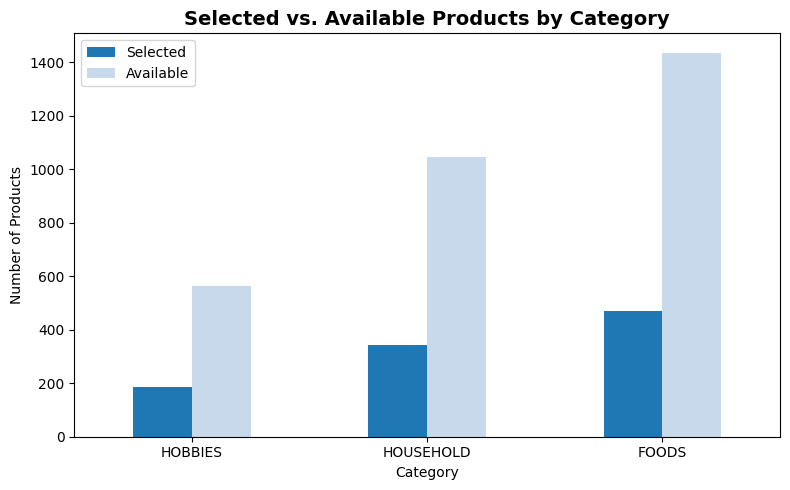

In [7]:
# --- Visualize how TOP_N was allocated across categories ---
plt.figure(figsize=(8, 5))
selection_summary = pd.DataFrame({
    'Selected': category_quota,
    'Available': category_item_counts,
})
selection_summary.plot(kind='bar', ax=plt.gca(), color=['#1f77b4', '#c7d9ea'])
plt.title('Selected vs. Available Products by Category', fontsize=14, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Number of Products')
plt.xticks(rotation=0)
plt.legend(title='')
plt.tight_layout()
plt.show()


The chart below confirms the category-balanced selection from Step 1: each
category contributes a share of `TOP_N` proportional to its number of
available products, rather than being dominated by the largest category.


## Step 2 — Chunked Feature Engineering Pipeline

Each batch of `CHUNK_SIZE` products is processed independently through
melt, merge, cleaning, and feature engineering, so memory usage never
scales with the full product/date grid at once.

For each chunk:

1. **Melt** — reshape from wide (`d_1 ... d_1913`) to long format: one row
   per item–store–day.
2. **Merge** — join with `calendar` on `d`, and with `sell_prices` (filtered
   to the same chunk) on the composite key
   `['store_id', 'item_id', 'wm_yr_wk']`; both merges are one-to-one, with no
   row duplication.
3. **Clean** — label missing calendar events explicitly, forward/backward-fill
   missing prices within each `(store_id, item_id)` series, remove exact
   duplicates, cap extreme sales outliers at the 99th percentile, and derive
   a `sales_log` column.
4. **Engineer features** — lag features (7/14/28 days) and rolling means
   (7/28 days), computed per `id` (the item–store combination, since a
   single store sells many products and each pairing is its own time
   series), plus calendar-derived features. Rows without a full 28-day lag
   history are dropped.
5. **Accumulate EDA statistics** — sums and counts only (never raw rows), so
   the analysis in the next section stays cheap regardless of how many
   chunks were processed.

Only the compact, feature-ready result of each chunk is kept; all
intermediate frames are released before the next chunk begins.


In [8]:
def fill_missing_events(df, event_cols=('event_name_1', 'event_type_1', 'event_name_2', 'event_type_2')):
    for col in event_cols:
        if col not in df.columns:
            continue
        if isinstance(df[col].dtype, pd.CategoricalDtype):
            if 'No_Event' not in df[col].cat.categories:
                df[col] = df[col].cat.add_categories('No_Event')
            df[col] = df[col].fillna('No_Event')
        else:
            df[col] = df[col].astype('object').fillna('No_Event').astype('category')
    return df


def impute_prices(df):
    # Forward/backward fill missing prices within each (store, item) series,
    # then drop rows that are still missing (genuinely inactive item/store combos).
    df['sell_price'] = df['sell_price'].astype(np.float32)
    df['sell_price'] = df.groupby(['store_id', 'item_id'], observed=True)['sell_price'] \
                          .transform(lambda x: x.ffill().bfill())
    return df


def handle_outliers_and_scale(df):
    upper_limit = df['sales'].quantile(0.99)
    df['sales'] = np.where(df['sales'] > upper_limit, upper_limit, df['sales']).astype('int16')
    df['sales_log'] = np.log1p(df['sales']).astype(np.float32)
    return df


def add_time_series_features(df, group_col='id', target='sales'):
    df = df.sort_values([group_col, 'date']).copy()

    for lag in [7, 14, 28]:
        df[f'lag_{lag}'] = df.groupby(group_col, observed=True)[target].shift(lag)

    for window in [7, 28]:
        df[f'rolling_mean_{window}'] = (
            df.groupby(group_col, observed=True)[target].shift(1).rolling(window).mean()
        )

    df['day_of_week'] = df['date'].dt.dayofweek
    df['month'] = df['date'].dt.month
    df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
    return df


In [9]:
import time

id_vars = ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']

# Running EDA accumulators — small partial aggregates, never raw rows
eda_cat_sales = []
eda_weekday_sales = []
eda_daily_sales = []
eda_event_sales = []
eda_state_revenue = []
eda_store_revenue = []
eda_price_bucket_sales = []
eda_sales_hist = []
eda_heatmap = []

# Fixed bin edges (independent of any single chunk) so partial histograms
# and price buckets can be summed safely across chunks.
SALES_HIST_BIN_EDGES = np.arange(0, 42, 1)  # 0-40 units/day, overflow folded into the last bin
PRICE_BUCKET_EDGES = [0, 2, 5, 10, 20, 50, np.inf]
PRICE_BUCKET_LABELS = ['<$2', '$2-5', '$5-10', '$10-20', '$20-50', '$50+']
eda_missing_counts = pd.Series(dtype='int64')
eda_duplicates_total = 0

model_ready_chunks = []
pipeline_start = time.time()


In [10]:
for chunk_num, chunk_items in enumerate(item_chunks, start=1):
    chunk_start = time.time()
    try:
        # 1. Filter + melt just this chunk
        chunk_wide = sales_wide[sales_wide['item_id'].isin(chunk_items)]
        chunk_long = chunk_wide.melt(id_vars=id_vars, var_name='d', value_name='sales')

        # 2. Merge with calendar (on 'd') and prices (composite key, no fan-out)
        chunk_long = chunk_long.merge(calendar, on='d', how='left')
        chunk_long.drop(columns=['d'], inplace=True)

        chunk_prices = sell_prices[sell_prices['item_id'].isin(chunk_items)].copy()
        chunk_prices['item_id'] = chunk_prices['item_id'].astype('category')
        chunk_prices['store_id'] = chunk_prices['store_id'].astype('category')
        chunk_long = chunk_long.merge(chunk_prices, on=['store_id', 'item_id', 'wm_yr_wk'], how='left')
        del chunk_prices

        chunk_long = reduce_mem_usage(chunk_long)

        # Track missing/duplicate counts before cleaning fixes them
        eda_missing_counts = eda_missing_counts.add(chunk_long.isnull().sum(), fill_value=0)
        eda_duplicates_total += chunk_long.duplicated().sum()

        # Raw sales distribution *before* outlier capping, for the EDA histogram
        raw_counts, _ = np.histogram(
            chunk_long['sales'].clip(upper=SALES_HIST_BIN_EDGES[-1]), bins=SALES_HIST_BIN_EDGES
        )
        eda_sales_hist.append(raw_counts)

        # 3. Clean
        chunk_long = fill_missing_events(chunk_long)
        chunk_long = impute_prices(chunk_long)
        chunk_long = chunk_long.drop_duplicates()
        chunk_long = handle_outliers_and_scale(chunk_long)
        chunk_long['revenue'] = chunk_long['sales'] * chunk_long['sell_price']

        # 4. Accumulate EDA aggregates from this chunk (partial sums, not raw rows)
        eda_cat_sales.append(chunk_long.groupby('cat_id', observed=True)['sales'].sum())
        eda_weekday_sales.append(chunk_long.groupby('weekday', observed=True)['sales'].agg(['sum', 'count']))
        eda_daily_sales.append(chunk_long.groupby('date', observed=True)['sales'].sum())
        eda_event_sales.append(chunk_long.groupby('event_type_1', observed=True)['sales'].agg(['sum', 'count']))
        eda_state_revenue.append(chunk_long.groupby('state_id', observed=True)['revenue'].sum())
        eda_store_revenue.append(chunk_long.groupby('store_id', observed=True)['revenue'].sum())

        chunk_long['price_bucket'] = pd.cut(
            chunk_long['sell_price'], bins=PRICE_BUCKET_EDGES, labels=PRICE_BUCKET_LABELS
        )
        eda_price_bucket_sales.append(
            chunk_long.groupby('price_bucket', observed=True)['sales'].agg(['sum', 'count'])
        )
        eda_heatmap.append(chunk_long.groupby(['cat_id', 'weekday'], observed=True)['sales'].agg(['sum', 'count']))

        # 5. Feature engineer, drop rows without full lag history yet, keep only what modeling needs
        chunk_long = add_time_series_features(chunk_long)
        chunk_model_ready = chunk_long.dropna(subset=['lag_28', 'rolling_mean_28']).copy()

        keep_cols = ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'date',
                     'sales', 'sales_log', 'sell_price', 'wday', 'snap_CA', 'snap_TX', 'snap_WI',
                     'lag_7', 'lag_14', 'lag_28', 'rolling_mean_7', 'rolling_mean_28',
                     'day_of_week', 'month', 'is_weekend']
        model_ready_chunks.append(chunk_model_ready[keep_cols].copy())

        elapsed = time.time() - chunk_start
        print(f'Chunk {chunk_num}/{len(item_chunks)}: {len(chunk_items)} products -> '
              f'{len(chunk_model_ready):,} model-ready rows ({elapsed:.1f}s)')
        print_memory_usage(f'after chunk {chunk_num}')

        del chunk_wide, chunk_long, chunk_model_ready

    except Exception as exc:
        # A single bad chunk (e.g. an unexpected key mismatch) shouldn't
        # silently corrupt the whole run — surface it clearly and stop.
        print(f'[error] Chunk {chunk_num} failed: {exc}')
        raise
    finally:
        gc.collect()

print(f'\nAll chunks processed in {time.time() - pipeline_start:.1f}s total.')


Chunk 1/5: 200 products -> 3,770,000 model-ready rows (17.0s)
[memory] after chunk 1: 2292.8 MB in use
Chunk 2/5: 200 products -> 3,770,000 model-ready rows (16.2s)
[memory] after chunk 2: 2709.2 MB in use
Chunk 3/5: 200 products -> 3,770,000 model-ready rows (15.7s)
[memory] after chunk 3: 3068.8 MB in use
Chunk 4/5: 200 products -> 3,770,000 model-ready rows (15.9s)
[memory] after chunk 4: 3399.6 MB in use
Chunk 5/5: 200 products -> 3,770,000 model-ready rows (15.7s)
[memory] after chunk 5: 3802.3 MB in use

All chunks processed in 81.5s total.


In [11]:
# Combine the small per-chunk results into the final modeling table and EDA aggregates
model_df = pd.concat(model_ready_chunks, ignore_index=True)
del model_ready_chunks
gc.collect()

sales_by_cat = pd.concat(eda_cat_sales).groupby(level=0).sum().reset_index(name='sales')

weekday_agg = pd.concat(eda_weekday_sales).groupby(level=0).sum()
sales_by_day = (weekday_agg['sum'] / weekday_agg['count']).reset_index(name='sales').rename(columns={'index': 'weekday'})

daily_sales = pd.concat(eda_daily_sales).groupby(level=0).sum().reset_index(name='sales').rename(columns={'index': 'date'})

event_agg = pd.concat(eda_event_sales).groupby(level=0).sum()
event_sales = (event_agg['sum'] / event_agg['count']).reset_index(name='sales').rename(columns={'index': 'event_type_1'})

state_revenue = pd.concat(eda_state_revenue).groupby(level=0).sum().reset_index(name='revenue')

heatmap_agg = pd.concat(eda_heatmap).groupby(level=[0, 1]).sum()
heatmap_data = (heatmap_agg['sum'] / heatmap_agg['count']).unstack()

print('Model-ready shape:', model_df.shape)
print_memory_usage('after combining all chunks')


Model-ready shape: (18850000, 22)
[memory] after combining all chunks: 3975.1 MB in use


In [12]:
sales_hist_counts = np.sum(eda_sales_hist, axis=0)

store_revenue = pd.concat(eda_store_revenue).groupby(level=0).sum().reset_index(name='revenue')

price_bucket_agg = pd.concat(eda_price_bucket_sales).groupby(level=0).sum()
price_bucket_sales = (
    (price_bucket_agg['sum'] / price_bucket_agg['count'])
    .reset_index(name='sales')
    .rename(columns={'index': 'price_bucket'})
)


---
## 2. Exploratory Data Analysis

All statistics below are computed from incrementally accumulated aggregates
rather than a fully materialized dataset, so this section's memory
footprint is independent of `TOP_N`. The analysis covers the selected
product mix, sales patterns by time and category, pricing behavior, and
geographic performance.


In [13]:
print('Missing values accumulated across chunks (before cleaning filled them):')
display(eda_missing_counts[eda_missing_counts > 0])
print(f'Duplicate rows removed across all chunks: {eda_duplicates_total}')

model_df.info(show_counts=True)


Missing values accumulated across chunks (before cleaning filled them):


,0
event_name_1,17590000.0
event_name_2,19090000.0
event_type_1,17590000.0
event_type_2,19090000.0
sell_price,2077817.0


Duplicate rows removed across all chunks: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18850000 entries, 0 to 18849999
Data columns (total 22 columns):
 #   Column           Non-Null Count     Dtype         
---  ------           --------------     -----         
 0   id               18850000 non-null  category      
 1   item_id          18850000 non-null  object        
 2   dept_id          18850000 non-null  category      
 3   cat_id           18850000 non-null  category      
 4   store_id         18850000 non-null  category      
 5   state_id         18850000 non-null  category      
 6   date             18850000 non-null  datetime64[ns]
 7   sales            18850000 non-null  int16         
 8   sales_log        18850000 non-null  float32       
 9   sell_price       18850000 non-null  float32       
 10  wday             18850000 non-null  int8          
 11  snap_CA          18850000 non-null  int8          
 12  snap_TX          18850000 non-null  int8          
 

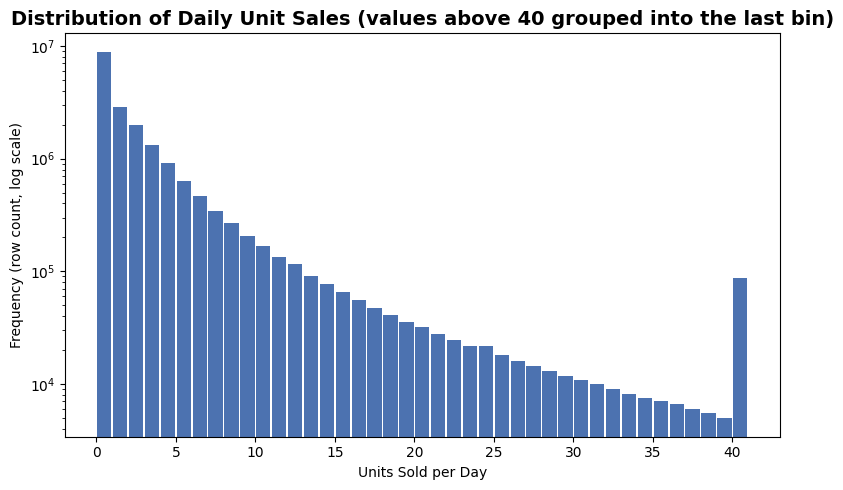

In [14]:
plt.figure(figsize=(8, 5))
bin_centers = (SALES_HIST_BIN_EDGES[:-1] + SALES_HIST_BIN_EDGES[1:]) / 2
plt.bar(bin_centers, sales_hist_counts, width=0.9, color='#4c72b0')
plt.title('Distribution of Daily Unit Sales (values above 40 grouped into the last bin)',
          fontsize=14, fontweight='bold')
plt.xlabel('Units Sold per Day')
plt.ylabel('Frequency (row count, log scale)')
plt.yscale('log')
plt.tight_layout()
plt.show()


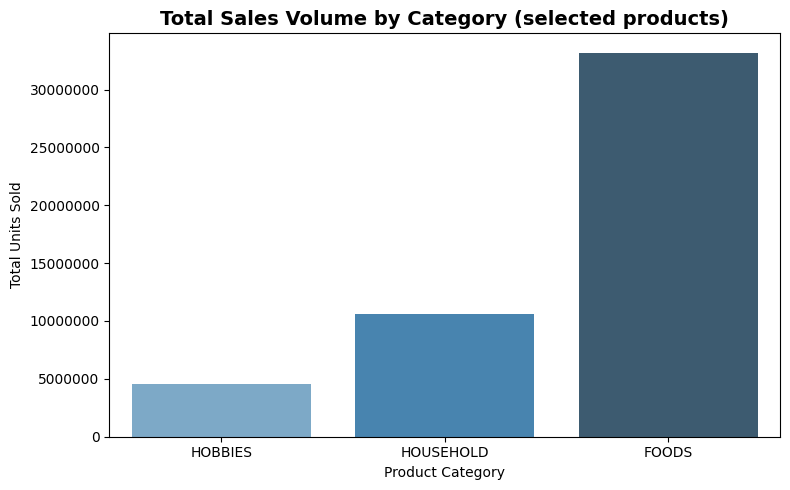

In [15]:
plt.figure(figsize=(8, 5))
sns.barplot(data=sales_by_cat, x='cat_id', y='sales', palette='Blues_d')
plt.title('Total Sales Volume by Category (selected products)', fontsize=14, fontweight='bold')
plt.xlabel('Product Category')
plt.ylabel('Total Units Sold')
plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.show()


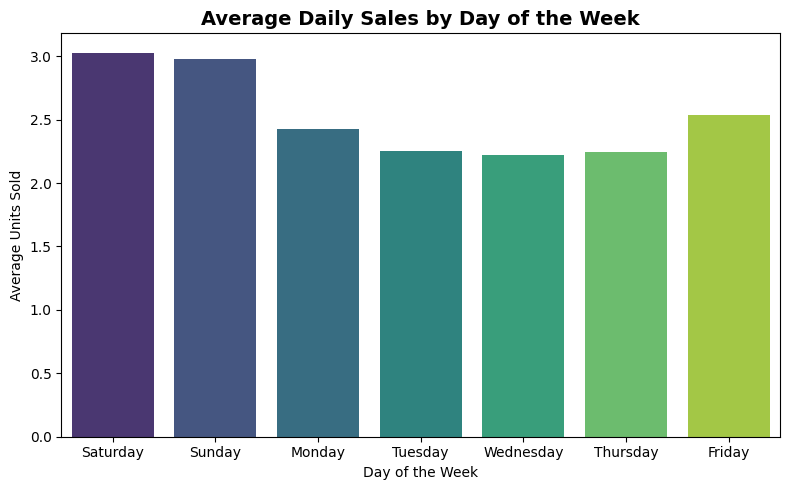

In [16]:
days_order = ['Saturday', 'Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
sales_by_day_ordered = sales_by_day.set_index('weekday').reindex(days_order).reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data=sales_by_day_ordered, x='weekday', y='sales', palette='viridis')
plt.title('Average Daily Sales by Day of the Week', fontsize=14, fontweight='bold')
plt.xlabel('Day of the Week')
plt.ylabel('Average Units Sold')
plt.tight_layout()
plt.show()


In [17]:
fig = px.line(
    daily_sales.sort_values('date'), x='date', y='sales',
    title='Interactive Daily Sales Trend (selected products)',
    labels={'date': 'Date', 'sales': 'Total Units Sold'},
    template='plotly_white'
)
fig.update_xaxes(rangeslider_visible=True)
fig.show()


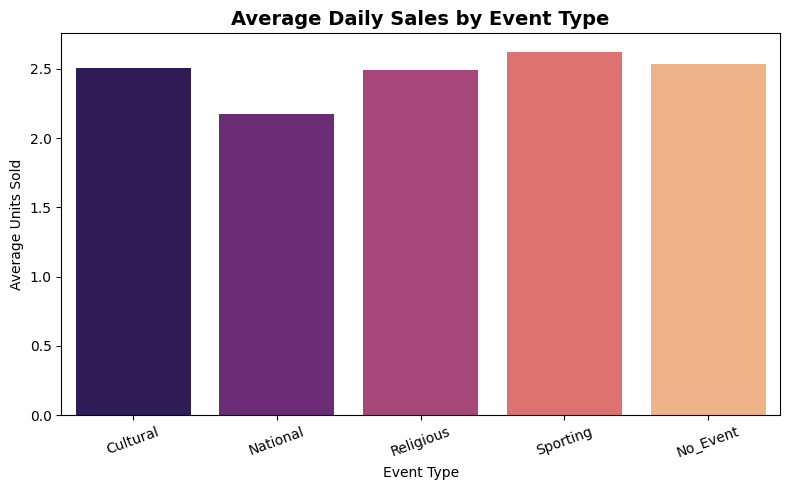

In [18]:
event_sales_sorted = event_sales.sort_values(by='sales', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=event_sales_sorted, x='event_type_1', y='sales', palette='magma')
plt.title('Average Daily Sales by Event Type', fontsize=14, fontweight='bold')
plt.xlabel('Event Type')
plt.ylabel('Average Units Sold')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


---
## 3. Data Cleaning & Preprocessing (Recap)

Cleaning is performed inside each chunk during Step 2 — calendar events
filled, prices imputed, duplicates removed, outliers capped, log-sales
derived — so the notebook never holds an uncleaned, full-size table at
once. This step verifies the final result and exports it.


In [19]:
def verify_and_export(df, file_name):
    print(f'Final Cleaned Dataframe Shape: {df.shape}')
    missing = df.isnull().sum()
    missing_count = missing[missing > 0]
    if missing_count.empty:
        print('Missing values check: PASSED!')
    else:
        print('Missing values check: FAILED! Missing values found:')
        display(missing_count)
    df.to_parquet(file_name, index=False)
    print(f'Saved cleaned data to {file_name}')

# Descriptive, self-explanatory filename (dataset + product count) rather
# than a bare number, so it's clear what the file contains at a glance.
cleaned_data_filename = f'm5_sales_features_{TOP_N}products.parquet'
verify_and_export(model_df, cleaned_data_filename)


Final Cleaned Dataframe Shape: (18850000, 22)
Missing values check: PASSED!
Saved cleaned data to m5_sales_features_1000products.parquet


### Business KPIs: Revenue, Pricing, and Store Performance

Beyond category- and state-level sales, this section looks at revenue by
state and by individual store, and the observed relationship between price
and demand — signals that are directly useful for inventory and pricing
decisions.


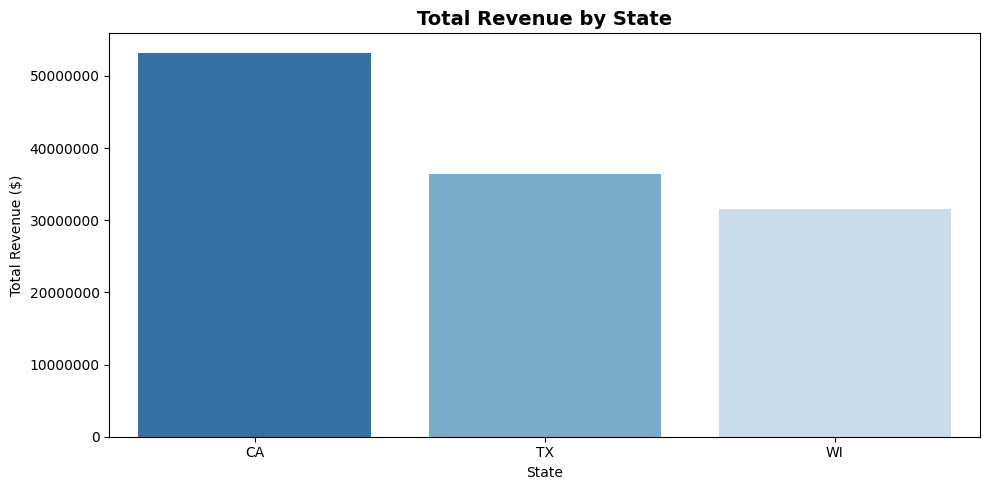

In [20]:
plt.figure(figsize=(10, 5))
sns.barplot(data=state_revenue, x='state_id', y='revenue', palette='Blues_r')
plt.title('Total Revenue by State', fontsize=14, fontweight='bold')
plt.xlabel('State')
plt.ylabel('Total Revenue ($)')
plt.ticklabel_format(style='plain', axis='y')
plt.tight_layout()
plt.show()


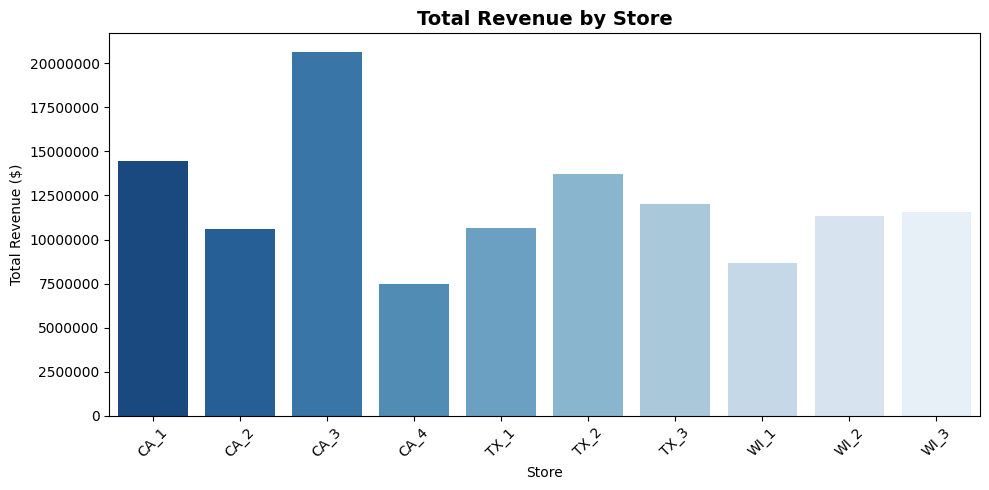

In [21]:
plt.figure(figsize=(10, 5))
store_revenue_sorted = store_revenue.sort_values('revenue', ascending=False)
sns.barplot(data=store_revenue_sorted, x='store_id', y='revenue', palette='Blues_r')
plt.title('Total Revenue by Store', fontsize=14, fontweight='bold')
plt.xlabel('Store')
plt.ylabel('Total Revenue ($)')
plt.ticklabel_format(style='plain', axis='y')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


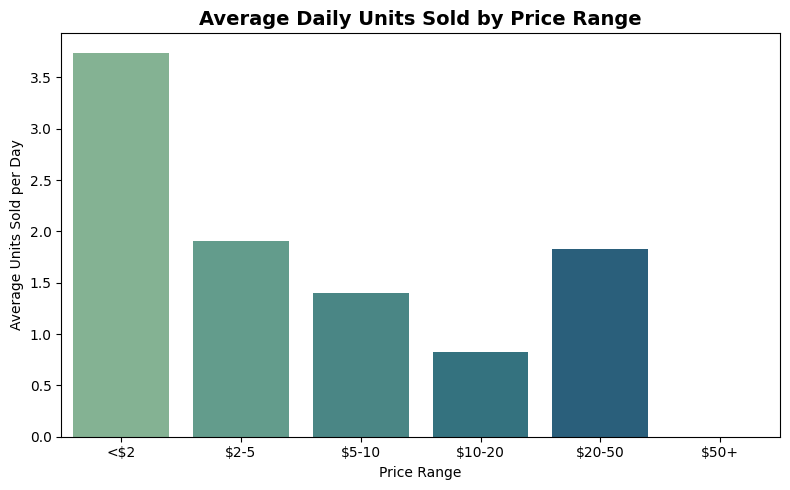

In [22]:
price_order = ['<$2', '$2-5', '$5-10', '$10-20', '$20-50', '$50+']
price_bucket_sales_ordered = price_bucket_sales.set_index('price_bucket').reindex(price_order).reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data=price_bucket_sales_ordered, x='price_bucket', y='sales', palette='crest')
plt.title('Average Daily Units Sold by Price Range', fontsize=14, fontweight='bold')
plt.xlabel('Price Range')
plt.ylabel('Average Units Sold per Day')
plt.tight_layout()
plt.show()


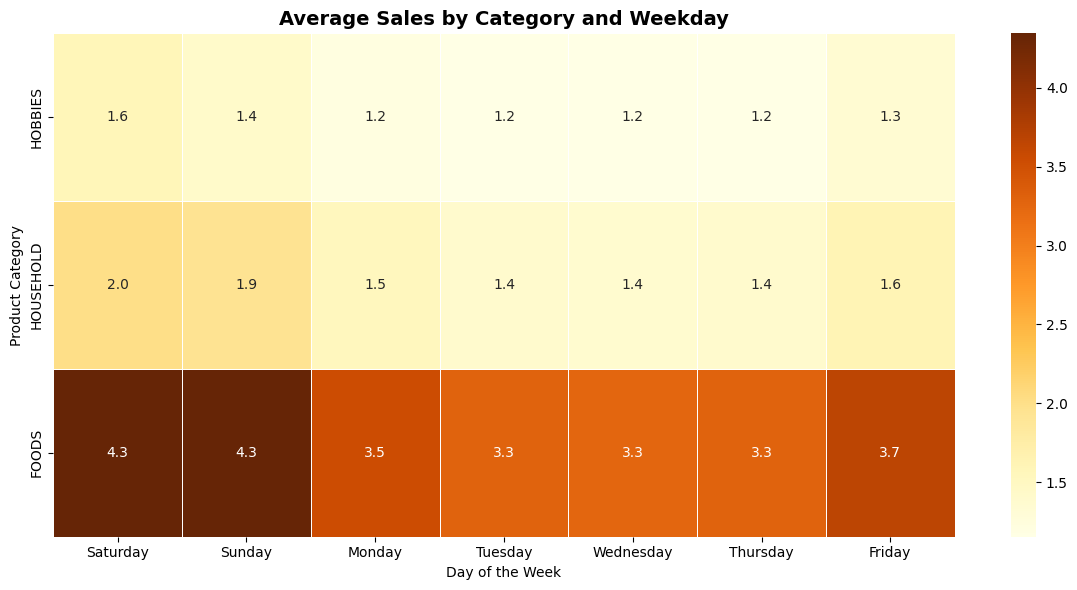

In [23]:
plt.figure(figsize=(12, 6))
heatmap_plot = heatmap_data[[d for d in days_order if d in heatmap_data.columns]]

sns.heatmap(heatmap_plot, annot=True, fmt='.1f', cmap='YlOrBr', linewidths=.5)
plt.title('Average Sales by Category and Weekday', fontsize=14, fontweight='bold')
plt.xlabel('Day of the Week')
plt.ylabel('Product Category')
plt.tight_layout()
plt.show()


---
## 4. Time-Series Feature Engineering (Recap)

Lag features (7/14/28 days) and rolling means (7/28 days) were computed per
chunk in Step 2, grouped by `id` rather than by `store_id` alone — since a
single store sells many products, and each product–store pairing is its own
independent time series. A preview of the result:


In [24]:
model_df[['id', 'date', 'sales', 'lag_7', 'lag_28', 'rolling_mean_7', 'rolling_mean_28']].tail()


,id,date,sales,lag_7,lag_28,rolling_mean_7,rolling_mean_28
18849995,FOODS_3_820_WI_3_validation,2016-04-20,1,2.0,1.0,1.142857,1.857143
18849996,FOODS_3_820_WI_3_validation,2016-04-21,3,1.0,2.0,1.000000,1.857143
18849997,FOODS_3_820_WI_3_validation,2016-04-22,6,1.0,3.0,1.285714,1.892857
18849998,FOODS_3_820_WI_3_validation,2016-04-23,0,1.0,2.0,2.000000,2.000000
18849999,FOODS_3_820_WI_3_validation,2016-04-24,1,0.0,2.0,1.857143,1.928571


---
## 5. Data Splitting (Chronological, Not Random)

The most recent 28 days form the test set; everything before that is used
for training. Because all product–store series share the same calendar, a
single global cutoff date applies uniformly across the dataset.


In [25]:
cutoff_date = model_df['date'].max() - pd.Timedelta(days=28)

train = model_df[model_df['date'] <= cutoff_date]
test = model_df[model_df['date'] > cutoff_date]

print('Train:', train.shape, train['date'].min(), '->', train['date'].max())
print('Test :', test.shape, test['date'].min(), '->', test['date'].max())


Train: (18570000, 22) 2011-02-26 00:00:00 -> 2016-03-27 00:00:00
Test : (280000, 22) 2016-03-28 00:00:00 -> 2016-04-24 00:00:00


---
## 6. Model Training & Evaluation — Baseline: XGBoost

`item_id`, `store_id`, `state_id`, `cat_id`, and `dept_id` are passed as
native pandas categoricals with `enable_categorical=True` — XGBoost's
histogram method handles these directly, avoiding manual one-hot or label
encoding.

Accuracy is reported with four metrics, since each tells a different story
for retail demand:

- **RMSE** — penalizes large misses heavily (sensitive to spikes and
  promotions).
- **MAE** — average error in the same units as sales (straightforward to
  interpret).
- **MAPE** — error as a percentage, comparable across products with very
  different volumes.
- **R²** — the share of variance in daily sales the model explains, with
  `1.0` being a perfect fit.


In [26]:
cat_features = ['item_id', 'store_id', 'state_id', 'cat_id', 'dept_id']
num_features = ['lag_7', 'lag_14', 'lag_28', 'rolling_mean_7', 'rolling_mean_28',
                 'sell_price', 'day_of_week', 'month', 'is_weekend', 'wday',
                 'snap_CA', 'snap_TX', 'snap_WI']
features = cat_features + num_features
target = 'sales'

# Cast categorical columns to pandas 'category' dtype so XGBoost's
# enable_categorical path can consume them directly (no manual encoding).
for col in cat_features:
    train[col] = train[col].astype('category')
    test[col] = test[col].astype('category')

X_train, y_train = train[features], train[target]
X_test, y_test = test[features], test[target]


/tmp/ipykernel_573/1352412456.py:11: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_573/1352412456.py:12: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_573/1352412456.py:11: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [27]:
def evaluate_model(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / np.maximum(y_true, 1))) * 100
    r2 = r2_score(y_true, y_pred)
    print(f'{model_name:>10} | RMSE: {rmse:6.3f} | MAE: {mae:6.3f} | MAPE: {mape:6.2f}% | R2: {r2:6.3f}')
    return {'model': model_name, 'rmse': rmse, 'mae': mae, 'mape': mape, 'r2': r2}


In [28]:
xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    tree_method='hist',
    enable_categorical=True,
)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

results = [evaluate_model(y_test, xgb_preds, 'XGBoost')]


   XGBoost | RMSE:  2.670 | MAE:  1.605 | MAPE:  76.64% | R2:  0.722


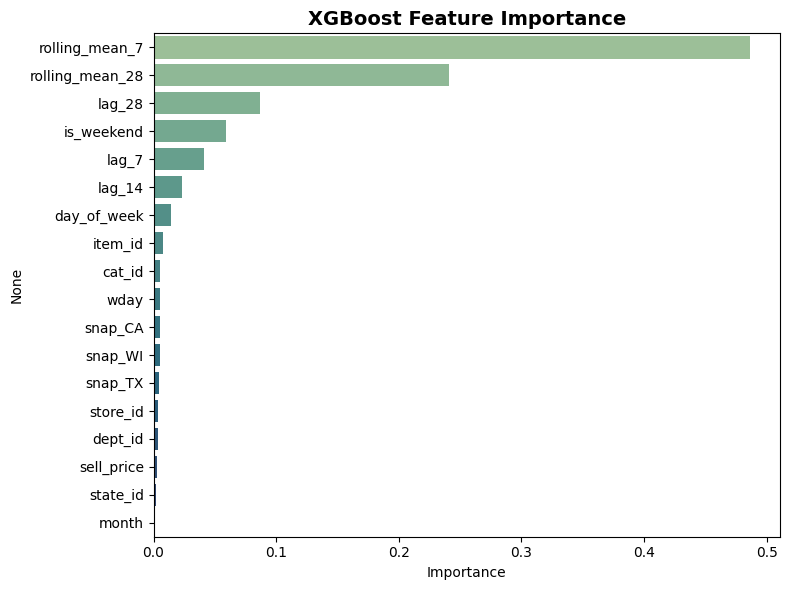

In [29]:
importances = pd.Series(xgb_model.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values, y=importances.index, palette='crest')
plt.title('XGBoost Feature Importance', fontsize=14, fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()


---
## 7. Model Comparison — LightGBM and an Optional Deep Learning Baseline

XGBoost is a strong default, but it's worth validating that against an
alternative before committing to it for deployment.

### LightGBM — the practical alternative

LightGBM uses histogram-based, leaf-wise tree growth, which typically makes
it faster to train and lighter on memory than XGBoost at comparable or
better accuracy on tabular data like this — a direct benefit for the same
scalability goals that motivated the chunked pipeline above. It also
consumes pandas categoricals natively, so the feature setup carries over
almost unchanged.

### Why Gradient Boosting Over Deep Learning Here

- Deep learning tends to outperform when there's a large volume of data per
  series, complex non-linear temporal dynamics, and enough compute for
  proper tuning. The M5 competition this dataset comes from was won
  predominantly by **LightGBM-based ensembles**, not deep learning —
  gradient boosting on well-engineered lag features has consistently
  matched or beaten RNN/LSTM approaches on this exact problem.
- An LSTM requires its own data pipeline (fixed-length sequences per `id`,
  padding for short series, feature scaling), a GPU for practical training
  times, and materially more tuning to match a boosted-tree baseline — real
  costs on a resource-constrained runtime.
- Deep learning is a better fit for very long series with complex
  seasonality, or when modeling many series jointly with shared
  representations (e.g. a global sequence model such as a Temporal Fusion
  Transformer or N-BEATS) rather than per-row tabular predictions.

The LSTM cell below is included as an optional, self-contained comparison —
set `RUN_DEEP_LEARNING = True` only on a GPU runtime, to confirm the
trade-off empirically. It is not required for the main pipeline to run.


In [30]:
lgb_model = lgb.LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
)

X_train_lgb = X_train.copy()
X_test_lgb = X_test.copy()
lgb_model.fit(X_train_lgb, y_train, categorical_feature=cat_features)
lgb_preds = lgb_model.predict(X_test_lgb)

results.append(evaluate_model(y_test, lgb_preds, 'LightGBM'))


[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 2.335417 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1944
[LightGBM] [Info] Number of data points in the train set: 18570000, number of used features: 18
[LightGBM] [Info] Start training from score 2.529817
  LightGBM | RMSE:  2.672 | MAE:  1.609 | MAPE:  76.95% | R2:  0.721


In [31]:
RUN_DEEP_LEARNING = False  # set True only on a GPU runtime; this is an optional comparison, not required

if RUN_DEEP_LEARNING:
    import tensorflow as tf
    from tensorflow.keras import layers, models
    from sklearn.preprocessing import StandardScaler

    SEQ_LEN = 28  # days of history used to predict the next day

    def make_sequences(df, feature_cols, target_col='sales', seq_len=SEQ_LEN):
        X_seq, y_seq = [], []
        for _, g in df.sort_values('date').groupby('id', observed=True):
            values = g[feature_cols].to_numpy(dtype='float32')
            target = g[target_col].to_numpy(dtype='float32')
            for i in range(len(g) - seq_len):
                X_seq.append(values[i:i + seq_len])
                y_seq.append(target[i + seq_len])
        return np.array(X_seq), np.array(y_seq)

    lstm_features = ['sales', 'sell_price', 'day_of_week', 'is_weekend']
    scaler = StandardScaler().fit(train[lstm_features])
    train_scaled = train.copy()
    test_scaled = test.copy()
    train_scaled[lstm_features] = scaler.transform(train[lstm_features])
    test_scaled[lstm_features] = scaler.transform(test[lstm_features])

    X_train_seq, y_train_seq = make_sequences(train_scaled, lstm_features)
    X_test_seq, y_test_seq = make_sequences(pd.concat([train_scaled.tail(SEQ_LEN * 50), test_scaled]), lstm_features)

    lstm_model = models.Sequential([
        layers.Input(shape=(SEQ_LEN, len(lstm_features))),
        layers.LSTM(64, return_sequences=True),
        layers.LSTM(32),
        layers.Dense(16, activation='relu'),
        layers.Dense(1),
    ])
    lstm_model.compile(optimizer='adam', loss='mse')
    lstm_model.fit(X_train_seq, y_train_seq, epochs=10, batch_size=64,
                   validation_split=0.1, verbose=1)

    lstm_preds = lstm_model.predict(X_test_seq).flatten()
    results.append(evaluate_model(y_test_seq, lstm_preds, 'LSTM'))
else:
    print('Deep learning comparison skipped (RUN_DEEP_LEARNING = False). '
          'See the markdown above for why this is usually the right call here.')


Deep learning comparison skipped (RUN_DEEP_LEARNING = False). See the markdown above for why this is usually the right call here.


In [32]:
comparison = pd.DataFrame(results).set_index('model')
display(comparison)

best_model_name = comparison['rmse'].idxmin()
print(f'Best model by RMSE: {best_model_name}')

model = xgb_model if best_model_name == 'XGBoost' else (lgb_model if best_model_name == 'LightGBM' else None)


,rmse,mae,mape,r2
model,,,,
XGBoost,2.669628,1.604892,76.643463,0.721522
LightGBM,2.671962,1.608828,76.948829,0.721035


Best model by RMSE: XGBoost


---
## 8. Recursive 28-Day Forecast & Deployment Artifacts

The test set above only measures accuracy on days actuals already exist
for. To forecast genuinely future days (beyond the last date in the data),
predictions are generated one day at a time and fed back in as the next
day's lag — necessary because `lag_7`/`lag_14` for day *N+1* depend on
values the model itself produced for days after the training data ends.

This uses whichever model scored best above. The result is saved to a
compact CSV. The Streamlit app reads this CSV directly rather than
re-running the model live — simpler and more robust for a deployed app,
since it avoids keeping category encodings perfectly in sync between
notebook and app.


In [33]:
def recursive_forecast(history_df, model, features, cat_features, horizon=28,
                       group_col='id', target='sales'):
    all_rows = []
    cat_dtypes = {c: history_df[c].dtype for c in cat_features}
    total_groups = history_df[group_col].nunique()

    for i, (key, g) in enumerate(history_df.groupby(group_col, observed=True), start=1):
        g = g.sort_values('date')
        if len(g) < 28:
            continue
        last_date = g['date'].max()
        series = g[target].astype(float).tolist()
        static = g.iloc[-1]

        for h in range(1, horizon + 1):
            next_date = last_date + pd.Timedelta(days=h)
            row = {
                'lag_7': series[-7], 'lag_14': series[-14], 'lag_28': series[-28],
                'rolling_mean_7': np.mean(series[-7:]), 'rolling_mean_28': np.mean(series[-28:]),
                'sell_price': static['sell_price'],
                'day_of_week': next_date.dayofweek, 'month': next_date.month,
                'is_weekend': int(next_date.dayofweek in [5, 6]),
                'wday': ((next_date.dayofweek + 2) % 7) + 1,
                'snap_CA': 0, 'snap_TX': 0, 'snap_WI': 0,
            }
            for c in cat_features:
                row[c] = static[c]

            X_row = pd.DataFrame([row])
            for c in cat_features:
                X_row[c] = X_row[c].astype(cat_dtypes[c])

            pred = float(max(0, model.predict(X_row[features])[0]))
            series.append(pred)
            all_rows.append({
                'id': key, 'item_id': static['item_id'], 'store_id': static['store_id'],
                'state_id': static['state_id'], 'date': next_date,
                'predicted_sales': round(pred, 2),
            })

        if i % 500 == 0 or i == total_groups:
            print(f'Forecasted {i}/{total_groups} product-store series...')

    return pd.DataFrame(all_rows)


In [34]:
for col in cat_features:
    model_df[col] = model_df[col].astype('category')

forecast_df = recursive_forecast(model_df, model, features, cat_features)
print(forecast_df.shape)
forecast_df.head()


Forecasted 500/10000 product-store series...
Forecasted 1000/10000 product-store series...
Forecasted 1500/10000 product-store series...
Forecasted 2000/10000 product-store series...
Forecasted 2500/10000 product-store series...
Forecasted 3000/10000 product-store series...
Forecasted 3500/10000 product-store series...
Forecasted 4000/10000 product-store series...
Forecasted 4500/10000 product-store series...
Forecasted 5000/10000 product-store series...
Forecasted 5500/10000 product-store series...
Forecasted 6000/10000 product-store series...
Forecasted 6500/10000 product-store series...
Forecasted 7000/10000 product-store series...
Forecasted 7500/10000 product-store series...
Forecasted 8000/10000 product-store series...
Forecasted 8500/10000 product-store series...
Forecasted 9000/10000 product-store series...
Forecasted 9500/10000 product-store series...
Forecasted 10000/10000 product-store series...
(280000, 6)


,id,item_id,store_id,state_id,date,predicted_sales
0,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,CA_1,CA,2016-04-25,1.93
1,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,CA_1,CA,2016-04-26,1.56
2,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,CA_1,CA,2016-04-27,1.70
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,CA_1,CA,2016-04-28,1.69
4,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,CA_1,CA,2016-04-29,2.20


In [35]:
import joblib

# Descriptive, self-explanatory filenames for every deployment artifact —
# the Streamlit app auto-discovers these by pattern (see streamlit_app.py).
forecast_filename = f'demand_forecast_28days_{TOP_N}products.csv'
history_filename = f'sales_history_90days_{TOP_N}products.csv'
model_filename = f'demand_forecast_model_{best_model_name.lower()}.pkl'

# Forecast table the Streamlit app will read (product + state dropdown -> chart)
forecast_df.to_csv(forecast_filename, index=False)

# Recent actuals, so the app can plot history + forecast on the same chart
history_tail = (
    model_df[['id', 'item_id', 'store_id', 'state_id', 'date', 'sales']]
    .groupby('id', observed=True)
    .apply(lambda g: g.sort_values('date').tail(90))
    .reset_index(drop=True)
)
history_tail.to_csv(history_filename, index=False)

# Keep the winning model too, for anyone who wants live inference later
joblib.dump(model, model_filename)

print(f'Saved: {forecast_filename}, {history_filename}, {model_filename} (model: {best_model_name})')


/tmp/ipykernel_573/1230664475.py:16: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



Saved: demand_forecast_28days_1000products.csv, sales_history_90days_1000products.csv, demand_forecast_model_xgboost.pkl (model: XGBoost)


---
## 9. Deployment (Streamlit)

Run the companion `app.py` with:

```bash
streamlit run app.py
```

It automatically discovers the most recently generated
`demand_forecast_28days_*products.csv` and `sales_history_90days_*products.csv`
files in its folder, lets the user pick a **state**, **store**, and
**product** (or upload a list of product IDs in bulk), and renders an
interactive chart of recent actual sales alongside the forecast, plus
summary KPIs and downloadable results.

## Conclusion & Next Steps

This pipeline processes products in memory-bounded chunks regardless of how
large `TOP_N` gets, streams EDA aggregates instead of holding the full
merged table, selects products in a category-balanced way so no category is
under-represented, and compares XGBoost against LightGBM (and optionally an
LSTM) on identical metrics before selecting a model for deployment. Natural
next steps from here:

- Push `TOP_N` up incrementally and watch the `print_memory_usage` output to
  find the largest value the runtime comfortably handles.
- Try per-category or per-store models if accuracy varies meaningfully by
  segment.
- Add prediction intervals (e.g. quantile regression with LightGBM) around
  the point forecast in the Streamlit app.
